# MAE Pretraining of Swin Transformer Encoder — Failure Demonstration

**Masked autoencoder** pretraining for 2D confocal microscopy patches.
**Strategy:** Mask random regions of the input, encode the corrupted image with Swin Transformer, decode with a CNN decoder, compute reconstruction loss only on the masked regions.

This notebook is *not* a full training run. Its purpose is to demonstrate that MAE pretraining is a poor fit for sparse fluorescence data and to produce a comparable artifact (singular value spectrum, log JSON, checkpoint) to the plain AE baseline so the two can be reported side by side in the thesis.

The structure mirrors `pretrain_ae_swin.ipynb` so saving and logging are directly comparable.

IMPORTANT: FIND REPLACE COMMENT FOR THING THAT PROBABLY SHOUD BE REPLACED

## A. Setup & Imports

In [2]:
import os, sys, time, math

# Prevent OpenBLAS from spawning too many threads (causes hangs on HPC)
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from tqdm.auto import tqdm

# Add project root to path (notebook lives in models/)
sys.path.insert(0, os.path.abspath("../.."))

from data_utils.patch_dataset import PatchDataset


In [3]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU")


NVIDIA A40
Memory: 47.7 GB


## B. Configuration

In [5]:
args = SimpleNamespace(
    # Data
    data_root="../../data/patches_128",
    val_split=0.2,
    seed=42,

    # Model
    in_channels=3,
    img_size=128,
    feature_size=48,
    spatial_dims=2,
    dropout_path_rate=0.0,
    use_checkpoint=False,

    # MAE-specific
    mask_block_size=16,        # mask in nxn pixel blocks
    mask_ratio=0.40,           # standard MAE masking ratio
    bright_weight=10.0,        # upweight bright pixels in MSE loss (kept for fair comparison with AE)
    loss_on_masked_only=True,  # standard MAE recipe
    mask_weight = 1.0,
    unmasked_weight = 0.1,

    # Training
    epochs=200,
    batch_size=32,
    lr=1.5e-4,
    weight_decay=0.05,
    warmup_epochs=10,

    # Output
    output_root="./outputs",
    experiment_counter=0,


    # IMPORTANT
    encoder_save_name="pretrained_encoder_mae.pt",
    experiment_name="pretrain_mae_swin",
    tag="16x16_40" # REPLACE
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

from datetime import datetime
run_timestamp = datetime.now().strftime("%Y_%m_%d_%H%M%S")
args.save_dir = os.path.join(args.output_root, f"{args.experiment_name}_{args.tag}_{run_timestamp}")
os.makedirs(args.save_dir, exist_ok=True)
print(f"Output directory: {args.save_dir}")

# Derived geometry — identical to AE notebook for direct comparability
args.patch_size    = 2
args.token_grid    = args.img_size // args.patch_size            # 64
args.window_size   = args.token_grid // 8                        # 8
args.enc_channels  = args.feature_size * (2 ** 4)                # 768
args.enc_spatial   = args.img_size // 32                         # 4
args.n_dec_upsample = int(math.log2(args.img_size // args.enc_spatial))  # 5

print(f"Mask block size:      {args.mask_block_size}x{args.mask_block_size} px")
print(f"Mask ratio:           {args.mask_ratio:.2f}")
print(f"Encoder output:       {args.enc_channels} ch, {args.enc_spatial}x{args.enc_spatial} spatial")


Device: cuda
Output directory: ./outputs/pretrain_mae_swin_16x16_40_2026_04_28_134423
Mask block size:      16x16 px
Mask ratio:           0.40
Encoder output:       768 ch, 4x4 spatial


## C. Dataset & DataLoaders

In [6]:
dataset = PatchDataset(root=args.data_root, exclude_patterns=["KONTROLA"])
print(f"Total patches: {len(dataset)}")

sample = dataset[0]
print(f"Sample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Value range:  [{sample.min():.4f}, {sample.max():.4f}]")
assert sample.ndim == 3
assert 0 <= sample.min() and sample.max() <= 1.0 + 1e-6

generator = torch.Generator().manual_seed(args.seed)
n_val = int(len(dataset) * args.val_split)
n_train = len(dataset) - n_val
train_dataset, val_dataset = random_split(dataset, [n_train, n_val], generator=generator)
print(f"Train: {n_train}, Validation: {n_val}")

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                          num_workers=0, pin_memory=True)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Total patches: 21708
Sample shape: torch.Size([3, 128, 128]), dtype: torch.float32
Value range:  [0.0000, 0.8915]
Train: 17367, Validation: 4341
Train batches: 543, Val batches: 136


## D. MAE Model (Encoder + CNN Decoder + Block Masking)

- **Encoder:** MONAI SwinTransformer (same configuration as the AE baseline)
- **Decoder:** ConvTranspose2d stack from the deepest stage feature map back to image resolution (same as AE)
- **Masking:** random block masking applied to the input image before encoding. Masked regions are filled with zeros, the standard SimMIM-style implementation.
- **Loss target:** the original (unmasked) image, but the loss is computed only on masked regions.


In [7]:
def gn_groups(c, max_groups=32):
    for g in (max_groups, 16, 8, 4, 2, 1):
        if c % g == 0:
            return g

In [8]:
from monai.networks.nets.swin_unetr import SwinTransformer

class MAESwinPretrainer(nn.Module):
    """MAE-style pretrainer with Swin Transformer encoder.

    Encoder (KEPT):  MONAI SwinTransformer -> deepest-stage spatial feature map
    Decoder (DISCARDED): ConvTranspose2d stack -> ____

    Input pipeline:
        x_orig (B,C,H,W)  ->  apply mask  ->  x_masked
        x_masked          ->  Swin encoder  ->  z (B, enc_ch, S, S)
        z                 ->  decoder        ->  x_recon (B,C,H,W)
        loss              ->  weighted MSE on masked regions of (x_recon, x_orig)
    """
    def __init__(self, args):
        super().__init__()

        patch_size  = (args.patch_size,) * args.spatial_dims
        window_size = (args.window_size,) * args.spatial_dims

        self.swinViT = SwinTransformer(
            in_chans=args.in_channels,
            embed_dim=args.feature_size,
            window_size=window_size,
            patch_size=patch_size,
            depths=[2, 2, 2, 2],
            num_heads=[3, 6, 12, 24],
            mlp_ratio=4.0,
            qkv_bias=True,
            drop_rate=0.0,
            attn_drop_rate=0.0,
            drop_path_rate=args.dropout_path_rate,
            norm_layer=torch.nn.LayerNorm,
            use_checkpoint=args.use_checkpoint,
            spatial_dims=args.spatial_dims,
        )

        enc_ch  = args.feature_size * (2 ** 4)
        spatial = args.img_size // 32
        n_ups   = int(math.log2(args.img_size // spatial))

        blocks = []
        in_ch = enc_ch
        for i in range(n_ups):
            is_last = (i == n_ups - 1)
            out_ch = args.in_channels if is_last else max(in_ch // 2, 32)
            blocks.append(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False)
            )
            if not is_last:
                blocks.append(nn.GroupNorm(num_groups=gn_groups(out_ch), num_channels=out_ch))
                blocks.append(nn.LeakyReLU(0.01, inplace=True))
            else:
                # SIGMOID BECAUSE INTESITY IS IN A RANGE 0 - 1???
                blocks.append(nn.Sigmoid()) 
            in_ch = out_ch
            
        self.decoder = nn.Sequential(*blocks)
    
        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, args.in_channels, 1, 1))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def encode(self, x):
        return self.swinViT(x.contiguous())[4]

    def encode_pooled(self, x):
        """Pooled patch descriptor for clustering / collapse diagnostics."""
        return self.encode(x).mean(dim=(2, 3))  # (B, enc_ch)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, mask):
        """x: (B,C,H,W) original, mask: (B,1,H,W) with 1 = masked.
        Returns reconstruction of the full image; loss is applied externally on masked regions only."""
        x_masked = x * (1.0 - mask) + self.mask_token * mask
        z = self.encode(x_masked)
        return self.decode(z)

print("model defined")

model defined


## F. Losses

Loss: weighted MSE applied only on masked regions, following the standard MAE recipe with the bright-pixel weighting carried over from the AE baseline so the two losses are directly comparable in scale.


In [9]:
def random_block_mask(img, block_size, mask_ratio):
    """Generate a random binary mask in (B, 1, H, W) where 1 = masked.

    Mask is generated at the block-grid resolution then upsampled to pixel
    resolution. This produces contiguous masked regions rather than scattered
    pixels, which matches the SimMIM / MAE recipe.
    """
    B, _, H, W = img.shape
    gh, gw = H // block_size, W // block_size
    n_blocks = gh * gw
    n_mask = int(round(n_blocks * mask_ratio))

    masks = []
    for _ in range(B):
        flat = torch.zeros(n_blocks, device=img.device)
        idx = torch.randperm(n_blocks, device=img.device)[:n_mask]
        flat[idx] = 1.0
        m = flat.view(1, 1, gh, gw)
        m = F.interpolate(m, scale_factor=block_size, mode="nearest")
        masks.append(m)
    return torch.cat(masks, dim=0)  # (B, 1, H, W)

def masked_weighted_mse(pred, target, mask, bright_weight=10.0):
    """MSE with per-pixel bright weighting, applied only on masked regions.

    pred, target: (B,C,H,W)
    mask: (B,1,H,W) with 1 = masked (loss-bearing) regions
    """
    bright = 1.0 + (bright_weight - 1.0) * target          # (B,C,H,W)
    diff_sq = (pred - target) ** 2                          # (B,C,H,W)
    weighted = bright * diff_sq                              # (B,C,H,W)
    # apply mask, average over masked pixels
    masked_loss = weighted * mask                            # (B,1,H,W) broadcast over C
    denom = mask.sum() * pred.shape[1] + 1e-8                # number of masked pixel-channels
    return masked_loss.sum() / denom

def masked_weighted_l1(pred, target, mask, mask_weight=1.0, unmask_weight=0.1, bright_weight=3):
    bright = 1.0 + (bright_weight - 1.0) * target.abs()  # use abs
    diff = (pred - target).abs() * bright
    weight = mask * mask_weight + (1 - mask) * unmask_weight
    return (diff * weight).mean()


def lr_lambda(epoch):
    if epoch < args.warmup_epochs:
        return epoch / max(1, args.warmup_epochs)
    progress = (epoch - args.warmup_epochs) / max(1, args.epochs - args.warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))
    
def normalize_target_per_block(target, block_size):
    B, C, H, W = target.shape
    bs = block_size
    t = target.unfold(2, bs, bs).unfold(3, bs, bs)  # (B,C,gh,gw,bs,bs)
    mean = t.mean(dim=(-1,-2), keepdim=True)
    std  = t.std(dim=(-1,-2), keepdim=True) + 1e-6
    t = (t - mean) / std
    return t.permute(0,1,2,4,3,5).reshape(B,C,H,W)

## G. Overfit Sanity Check

Verify the MAE setup can memorize 4 patches. If MAE cannot overfit on 4 samples, the failure on the full dataset is a code bug, not a data property. If MAE can overfit but fails to generalize, the failure is the structural mismatch between the masked-prediction pretext and sparse fluorescence data.


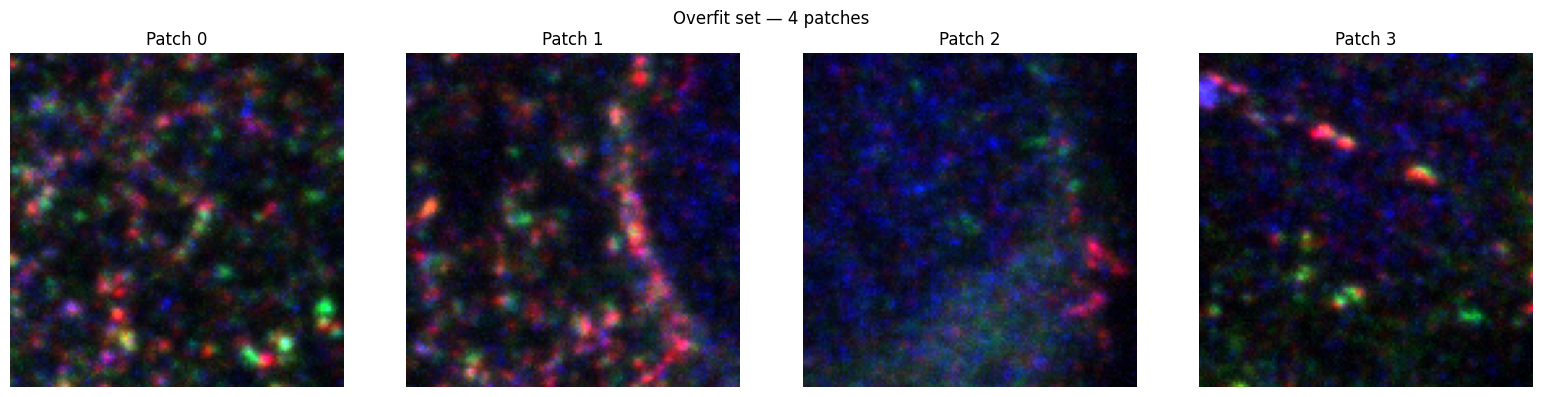

In [10]:
x_fixed = torch.stack([dataset[50], dataset[3], dataset[4], dataset[1000]]).to(device)
# x_fixed = Subset(dataset, range(16))

# Visualize the four patches (mean across channels for grayscale)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    img = x_fixed[i].cpu()
    ax.imshow(img.permute(1, 2, 0).numpy() if img.shape[0] >= 3 else img[0].numpy(), cmap="gray")
    ax.set_title(f"Patch {i}")
    ax.axis("off")
plt.suptitle("Overfit set — 4 patches")
plt.tight_layout()
plt.show()

In [11]:
model = MAESwinPretrainer(args).to(device)

total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.swinViT.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())
print(f"Total params:   {total_params:,}")
print(f"Encoder params: {encoder_params:,}")
print(f"Decoder params: {decoder_params:,}")

Total params:   12,582,861
Encoder params: 6,312,234
Decoder params: 6,270,624


In [12]:
overfir_lr = 1e-4

In [13]:
# Overfit MAE on 4 patches with a fixed mask per patch
model.train()
# opt_test = torch.optim.Adam(model.parameters(), lr=5e-4)
opt_test = torch.optim.Adam(model.parameters(), lr=overfir_lr)

# Fix the mask so we are testing memorization, not robustness to mask sampling
torch.manual_seed(args.seed)
fixed_mask = random_block_mask(x_fixed, args.mask_block_size, args.mask_ratio)

scaler_test = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

In [14]:
max_steps = 3000

In [15]:
loss_history = []

In [16]:
for step in tqdm(range(max_steps), desc="MAE overfit"):
    opt_test.zero_grad(set_to_none=True)
    with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
        recon = model(x_fixed, fixed_mask)
        # recon_norm = normalize_target_per_block(recon, args.mask_block_size)
        # target_norm = normalize_target_per_block(x_fixed, args.mask_block_size)
        # loss = masked_weighted_l1(recon_norm, target_norm, fixed_mask, 
        #                         mask_weight=1.0, unmask_weight=0.1, 
        #                         bright_weight=3.0,
        #                          )
        loss = masked_weighted_l1(recon, x_fixed, fixed_mask, mask_weight=1.0, unmask_weight=0.1, bright_weight=10.0,)
        
    scaler_test.scale(loss).backward()
    scaler_test.step(opt_test)
    scaler_test.update()
    loss_history.append(loss.item())
    if step % 100 == 0:
        tqdm.write(f"Step {step:4d} | loss: {loss.item():.6f}")
        
print(f"Final loss: {loss_history[-1]:.6f}")

MAE overfit:   0%|          | 0/3000 [00:00<?, ?it/s]

Step    0 | loss: 0.368286
Step  100 | loss: 0.085992
Step  200 | loss: 0.042881
Step  300 | loss: 0.029951
Step  400 | loss: 0.023372
Step  500 | loss: 0.019532
Step  600 | loss: 0.016862
Step  700 | loss: 0.015284
Step  800 | loss: 0.013855
Step  900 | loss: 0.012828
Step 1000 | loss: 0.012124
Step 1100 | loss: 0.011408
Step 1200 | loss: 0.010911
Step 1300 | loss: 0.010341
Step 1400 | loss: 0.009780
Step 1500 | loss: 0.009542
Step 1600 | loss: 0.009157
Step 1700 | loss: 0.008874
Step 1800 | loss: 0.008591
Step 1900 | loss: 0.008334
Step 2000 | loss: 0.008116
Step 2100 | loss: 0.007936
Step 2200 | loss: 0.007719
Step 2300 | loss: 0.007444
Step 2400 | loss: 0.007363
Step 2500 | loss: 0.007209
Step 2600 | loss: 0.006915
Step 2700 | loss: 0.006797
Step 2800 | loss: 0.006870
Step 2900 | loss: 0.006601
Final loss: 0.006445


In [17]:
# Per-sample MSE on the overfit set (masked regions only)
model.eval()
with torch.no_grad():
    recon = model(x_fixed, fixed_mask)
    for i in range(len(x_fixed)):
        m = fixed_mask[i:i+1]
        diff_sq = (recon[i:i+1] - x_fixed[i:i+1]) ** 2
        per_sample = (diff_sq * m).sum() / (m.sum() * x_fixed.shape[1] + 1e-8)
        print(f"Patch {i}: masked MSE = {per_sample.item():.6f}")


Patch 0: masked MSE = 0.000125
Patch 1: masked MSE = 0.000105
Patch 2: masked MSE = 0.000098
Patch 3: masked MSE = 0.000157


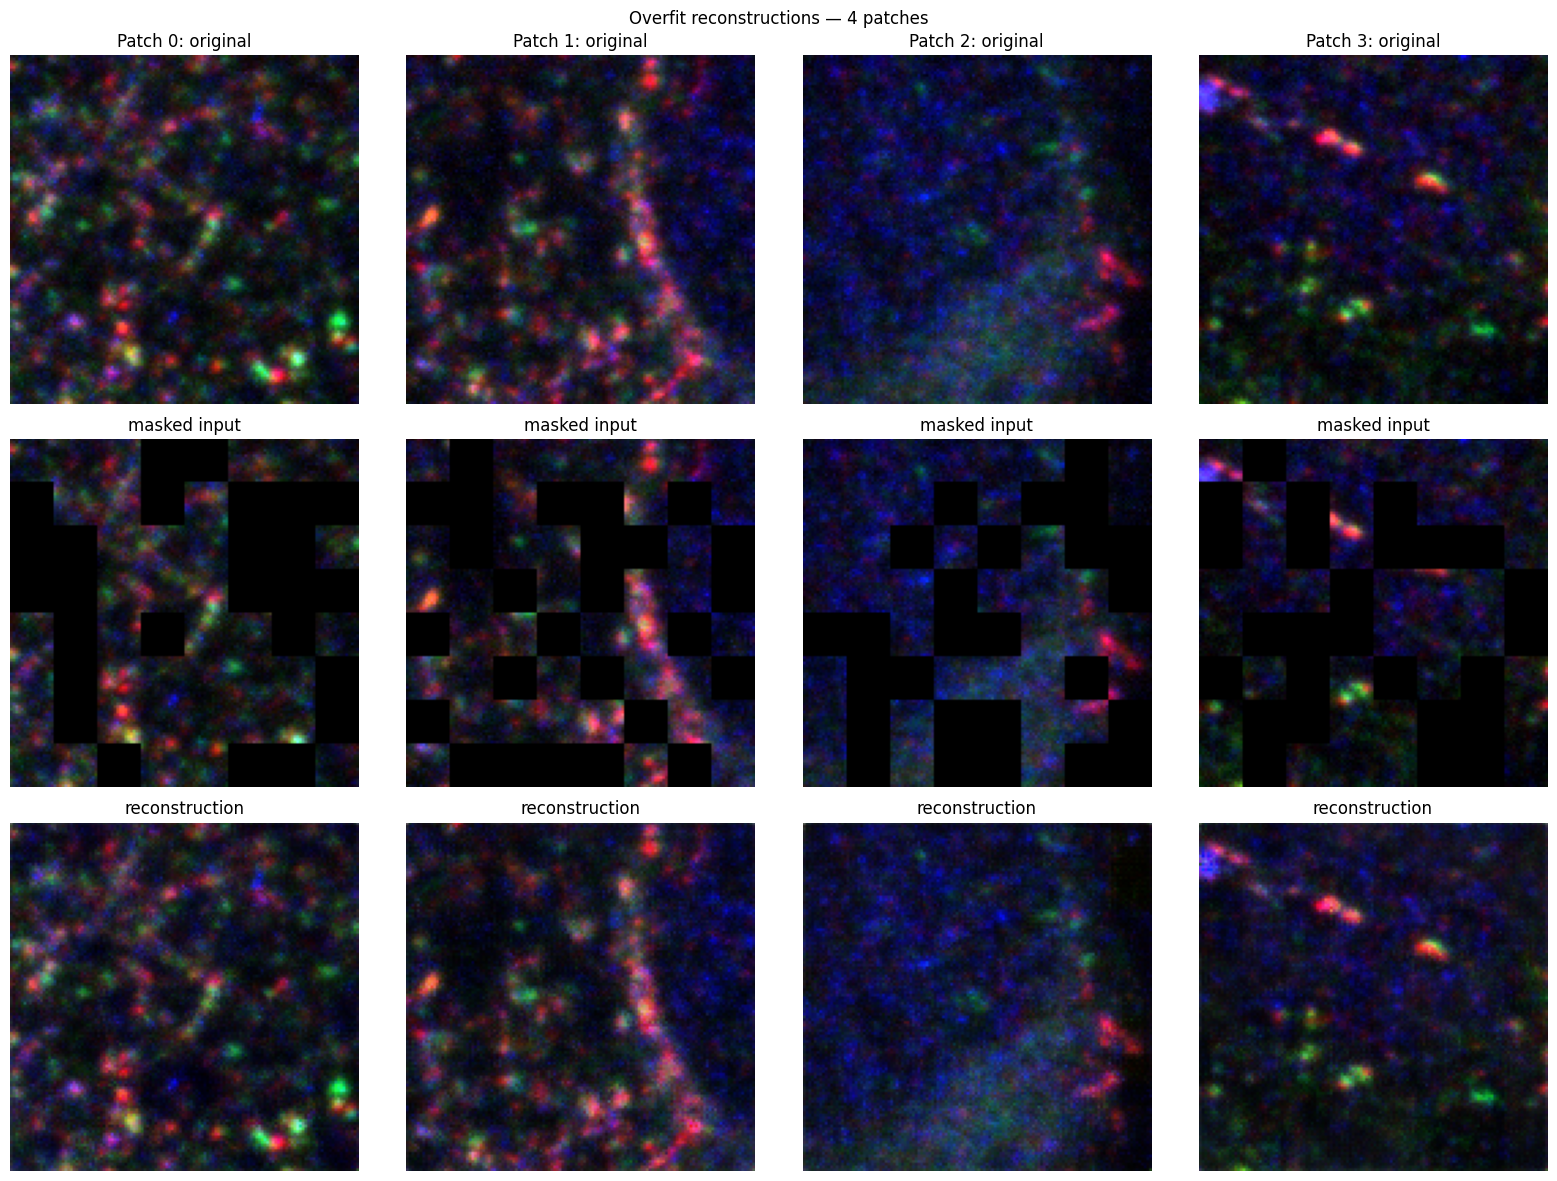

In [18]:
# Visual reconstruction of the overfit set
model.eval()
with torch.no_grad():
    recon = model(x_fixed, fixed_mask)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i in range(4):
    orig    = x_fixed[i].cpu().permute(1, 2, 0).numpy()
    masked  = (x_fixed[i] * (1 - fixed_mask[i])).cpu().permute(1, 2, 0).numpy()
    rec     = recon[i].cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig);   axes[0, i].set_title(f"Patch {i}: original");  axes[0, i].axis("off")
    axes[1, i].imshow(masked); axes[1, i].set_title("masked input");          axes[1, i].axis("off")
    axes[2, i].imshow(rec);    axes[2, i].set_title("reconstruction");        axes[2, i].axis("off")
plt.suptitle("Overfit reconstructions — 4 patches")
plt.tight_layout()
plt.show()

In [19]:
# Save overfit checkpoint and JSON log
import json
overfit_ckpt_path = os.path.join(args.save_dir, "overfit_sanity_check_mae.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": opt_test.state_dict(),
    "fixed_mask": fixed_mask.cpu(),
    "overfit_steps": len(loss_history),
    "final_loss": loss_history[-1],
}, overfit_ckpt_path)
print(f"Saved overfit checkpoint: {overfit_ckpt_path}")

run_tag = "_40_16x16"
log = {
    "timestamp": datetime.now().isoformat(),
    "run_tag": run_tag,
    "experiment_counter": args.experiment_counter,
    "experiment": "overfit_sanity_check_mae",
    "model": "MAESwinPretrainer",
    "config": {k: v for k, v in vars(args).items() if isinstance(v, (int, float, str, bool))},
    "overfit": {
        "n_samples": len(x_fixed),
        "steps": len(loss_history),
        "optimizer": type(opt_test).__name__,
        "lr": overfir_lr,
        "final_masked_weighted_mse": loss_history[-1],
    },
    "device": str(device),
}
log_path = os.path.join(args.save_dir, f"overfit_mae_{run_tag}_log.json")
with open(log_path, "w") as f:
    json.dump(log, f, indent=2)
print(f"Saved experiment log: {log_path}")


Saved overfit checkpoint: ./outputs/pretrain_mae_swin_16x16_40_2026_04_28_134423/overfit_sanity_check_mae.pt
Saved experiment log: ./outputs/pretrain_mae_swin_16x16_40_2026_04_28_134423/overfit_mae__40_16x16_log.json


## H. Re-initialize and Run Short Training

Re-initialize the encoder and run a short training (small number of epochs). The intent is to capture the same training-curve and diagnostic artifacts as the AE baseline so the two can be reported together. This is not a tuned MAE training.


In [32]:
args.lr=1.5e-4
warmup_epochs=5

In [33]:
model = MAESwinPretrainer(args).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("Model re-initialized.")

Model re-initialized.


### Training metadata + CSV logger

In [34]:
import csv

experiment_meta = {
    "experiment_name":   args.experiment_name,
    "start_time":        datetime.now().isoformat(),
    "device":            str(device),
    "gpu_name":          torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "pytorch_version":   torch.__version__,
    "cuda_version":      torch.version.cuda if torch.cuda.is_available() else "N/A",

    "n_train":           len(train_loader.dataset),
    "n_val":             len(val_loader.dataset),
    "n_train_batches":   len(train_loader),
    "n_val_batches":     len(val_loader),
    "patch_size_px":     args.img_size,
    "in_channels":       args.in_channels,

    "encoder":           "SwinTransformer (MONAI, spatial_dims=2)",
    "feature_size":      args.feature_size,
    "enc_channels":      args.enc_channels,
    "enc_spatial":       args.enc_spatial,
    "window_size":       args.window_size,
    "decoder":           f"ConvTranspose2d x{args.n_dec_upsample} stages",
    "total_params":      sum(p.numel() for p in model.parameters()),
    "encoder_params":    sum(p.numel() for p in model.swinViT.parameters()),
    "decoder_params":    sum(p.numel() for p in model.decoder.parameters()),

    "mae_mask_block_size": args.mask_block_size,
    "mae_mask_ratio":      args.mask_ratio,
    "loss_fn":             f"masked_weighted_mse (bright_weight={args.bright_weight})",

    "optimizer":         "AdamW",
    "lr":                args.lr,
    "weight_decay":      args.weight_decay,
    "batch_size":        args.batch_size,
    "epochs":            args.epochs,
    "warmup_epochs":     args.warmup_epochs,
    "scheduler":         "linear warmup + cosine decay",
    "mixed_precision":   device.type == "cuda",
    "grad_clip_norm":    1.0,
    "seed":              args.seed,
}

In [35]:
args.grad_clip_norm = 1.0

In [36]:
print("=" * 60)
print(f"Experiment: {experiment_meta['experiment_name']}")
print(f"Device:     {experiment_meta['gpu_name']}")
print(f"Train:      {experiment_meta['n_train']} patches, {experiment_meta['n_train_batches']} batches")
print(f"Val:        {experiment_meta['n_val']} patches, {experiment_meta['n_val_batches']} batches")
print(f"Params:     {experiment_meta['total_params']:,}")
print(f"Mask:       {experiment_meta['mae_mask_ratio']:.0%} of {experiment_meta['mae_mask_block_size']}px blocks")
print("=" * 60)

Experiment: pretrain_mae_swin
Device:     NVIDIA A40
Train:      17367 patches, 543 batches
Val:        4341 patches, 136 batches
Params:     12,582,861
Mask:       40% of 16px blocks


In [37]:
# ── Resume from checkpoint (set to None for fresh training) ──
#PERLACE
resume_dir = None  # e.g. "./outputs/pretrain_mae_swin_16x16_40_2026_04_27_193541"
# resume_dir = "./outputs/pretrain_mae_swin_16x16_40_2026_04_28_122820"

start_epoch    = 1
best_val_loss  = float("inf")
best_epoch     = 0
train_losses   = []
val_losses     = []
lr_history     = []
grad_norms     = []
epoch_times    = []

if resume_dir is not None:
    ckpt_path = os.path.join(resume_dir, "latest_mae_checkpoint.pt")

    assert os.path.isfile(ckpt_path), f"Checkpoint not found: {ckpt_path}"
    ckpt = torch.load(ckpt_path, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    start_epoch    = ckpt["epoch"] + 1
    best_val_loss  = ckpt["best_val_loss"]
    best_epoch     = ckpt["best_epoch"]
    train_losses   = ckpt["train_losses"]
    val_losses     = ckpt["val_losses"]
    lr_history     = ckpt["lr_history"]
    grad_norms     = ckpt["grad_norms"]
    epoch_times    = ckpt["epoch_times"]

    # Also point save_dir to the same folder so new files go there
    args.save_dir = resume_dir

    print(f"Resumed from epoch {ckpt['epoch']} (best_val={best_val_loss:.6f} @ epoch {best_epoch})")
    print(f"Continuing from epoch {start_epoch}")
else:
    print(f"Fresh training from epoch 1")


Fresh training from epoch 1


In [38]:
csv_path = os.path.join(args.save_dir, f"{args.experiment_name}_log.csv")
csv_fields = ["epoch", "train_loss", "val_loss", "lr",
              "epoch_time_s", "train_time_s", "val_time_s",
              "best_val_loss", "best_epoch",
              "grad_norm_mean", "grad_norm_max"]

# If resuming, append to existing CSV; otherwise create new
if start_epoch > 1 and os.path.exists(csv_path):
    csv_file = open(csv_path, "a", newline="")
    csv_writer = csv.DictWriter(csv_file, fieldnames=csv_fields)
    print(f"Appending to existing log: {csv_path}")
else:
    csv_file = open(csv_path, "w", newline="")
    csv_writer = csv.DictWriter(csv_file, fieldnames=csv_fields)
    csv_writer.writeheader()
    print(f"Logging to: {csv_path}")


Logging to: ./outputs/pretrain_mae_swin_16x16_40_2026_04_28_134423/pretrain_mae_swin_log.csv


In [ ]:
total_train_start = time.time()
scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

for epoch in range(start_epoch, args.epochs + 1):
    # --- Training ---
    model.train()
    running_loss = 0.0
    epoch_grad_norms = []
    train_start = time.time()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{args.epochs} [train]", leave=False)
    for batch_idx, x in enumerate(pbar, 1):
        x = x.to(device, non_blocking=True)
        mask = random_block_mask(x, args.mask_block_size, args.mask_ratio)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
            recon = model(x, mask)
            loss  = masked_weighted_l1(
                recon, x, mask,
                mask_weight=args.mask_weight,
                unmask_weight=args.unmasked_weight,
                bright_weight=args.bright_weight,
            )
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer) 
        total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=args.grad_clip_norm) # <--- CLIP
        # total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        epoch_grad_norms.append(total_norm.item())
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / batch_idx:.6f}")

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_time = time.time() - train_start
    scheduler.step()

    # --- Validation ---
    model.eval()
    val_running_loss = 0.0
    val_start = time.time()
    with torch.no_grad():
        for x in tqdm(val_loader, desc=f"Epoch {epoch}/{args.epochs} [val]", leave=False):
            x = x.to(device, non_blocking=True)
            mask = random_block_mask(x, args.mask_block_size, args.mask_ratio)
            with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
                recon = model(x, mask)
                loss  = masked_weighted_l1(
                    recon, x, mask,
                    mask_weight=args.mask_weight,
                    unmask_weight=args.unmasked_weight,
                    bright_weight=args.bright_weight,
                )
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)
    val_time = time.time() - val_start

    current_lr = scheduler.get_last_lr()[0]
    lr_history.append(current_lr)
    epoch_time = train_time + val_time
    epoch_times.append(epoch_time)
    mean_grad = sum(epoch_grad_norms) / len(epoch_grad_norms)
    max_grad  = max(epoch_grad_norms)
    grad_norms.append(mean_grad)

    improved = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        improved = " *best*"
        torch.save({
            "epoch":               epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":            val_loss,
            "train_loss":          train_loss,
            "args":                vars(args),
        }, os.path.join(args.save_dir, "best_mae_model.pt"))

    # Save latest checkpoint every epoch for resume
    torch.save({
        "epoch":               epoch,
        "model_state_dict":    model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict":   scaler.state_dict(),
        "val_loss":            val_loss,
        "train_loss":          train_loss,
        "best_val_loss":       best_val_loss,
        "best_epoch":          best_epoch,
        "train_losses":        train_losses,
        "val_losses":          val_losses,
        "lr_history":          lr_history,
        "grad_norms":          grad_norms,
        "epoch_times":         epoch_times,
        "args":                vars(args),
    }, os.path.join(args.save_dir, "latest_mae_checkpoint.pt"))

    print(f"Epoch {epoch:3d}/{args.epochs} | "
          f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
          f"LR: {current_lr:.2e} | "
          f"Time: {epoch_time:.1f}s | "
          f"GradNorm: {mean_grad:.3f}{improved}")

    csv_writer.writerow({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "lr": current_lr,
        "epoch_time_s": epoch_time,
        "train_time_s": train_time,
        "val_time_s": val_time,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "grad_norm_mean": mean_grad,
        "grad_norm_max": max_grad,
    })
    csv_file.flush()

total_train_time = time.time() - total_train_start
csv_file.close()
print(f"\nTotal training time: {total_train_time/60:.1f} min")


Epoch 1/200 [train]:   0%|          | 0/543 [00:00<?, ?it/s]

### Save experiment summary

In [1]:
experiment_meta["end_time"]         = datetime.now().isoformat()
experiment_meta["total_time_hours"] = round(total_train_time / 3600, 3)
experiment_meta["best_val_loss"]    = best_val_loss
experiment_meta["best_epoch"]       = best_epoch
experiment_meta["final_train_loss"] = train_losses[-1]
experiment_meta["final_val_loss"]   = val_losses[-1]

meta_path = os.path.join(args.save_dir, f"{args.experiment_name}_meta.json")
with open(meta_path, "w") as f:
    json.dump(experiment_meta, f, indent=2)
print(f"Saved metadata: {meta_path}")


NameError: name 'datetime' is not defined

## I. Failure Diagnostics

Three diagnostics produce evidence that MAE pretraining is mismatched to this data.

1. Loss curves: train and validation loss as functions of epoch.
2. Puncta vs background loss decomposition: split the masked-region loss into pixels that contained puncta and pixels that contained background. If the model has learned anything useful, the loss on puncta-containing regions should be lower than the loss obtained by predicting the per-image mean intensity.
3. Dimensional collapse on the pooled encoder output, identical to the AE diagnostic for direct comparison.


### Diagnostic 1: Loss curves

In [ ]:
epochs_range = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_range, train_losses, label="Train")
axes[0].plot(epochs_range, val_losses,   label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("masked weighted MSE")
axes[0].set_title("Loss (linear)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(epochs_range, train_losses, label="Train")
axes[1].semilogy(epochs_range, val_losses,   label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("masked weighted MSE (log)")
axes[1].set_title("Loss (log)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f"MAE training — {args.experiment_name}")
plt.tight_layout()
fig.savefig(os.path.join(args.save_dir, "loss_curves.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(args.save_dir, "loss_curves.png"), dpi=200, bbox_inches="tight")
plt.show()


### Diagnostic 2: Puncta vs background loss decomposition

Split the validation masked-region MSE into two strata, masked pixels containing puncta intensity (above a threshold in the original image) and masked pixels containing only background. Compare both to a trivial baseline that predicts the per-image mean intensity at every masked pixel.

If the MAE model is learning anything beyond mean-intensity prediction, its puncta-region MSE should beat the mean-intensity baseline. If the two are comparable, the model is satisfying the loss by predicting near-uniform intensity, which is the failure mode argued for in the thesis.


In [ ]:
# Threshold for "puncta pixel" in the original image. Tune to match your normalisation.
PUNCTA_THRESHOLD = 0.2   # pixels above this in the (already normalised) image are counted as puncta

model.eval()
puncta_sq_err  = 0.0
puncta_count   = 0
back_sq_err    = 0.0
back_count     = 0
baseline_puncta_sq = 0.0
baseline_back_sq   = 0.0

with torch.no_grad():
    for x in tqdm(val_loader, desc="Loss decomposition"):
        x = x.to(device, non_blocking=True)
        mask = random_block_mask(x, args.mask_block_size, args.mask_ratio)
        recon = model(x, mask)

        per_image_mean = x.mean(dim=(1, 2, 3), keepdim=True)        # (B,1,1,1)
        baseline = torch.full_like(x, 0.0) + per_image_mean

        # masked region only: build a (B,C,H,W) loss map and a (B,C,H,W) puncta indicator
        m = mask.expand_as(x)                                        # (B,C,H,W)
        is_puncta = (x > PUNCTA_THRESHOLD).float() * m
        is_back   = (1.0 - is_puncta) * m

        sq_model    = (recon - x) ** 2
        sq_baseline = (baseline - x) ** 2

        puncta_sq_err += (sq_model * is_puncta).sum().item()
        back_sq_err   += (sq_model * is_back).sum().item()
        baseline_puncta_sq += (sq_baseline * is_puncta).sum().item()
        baseline_back_sq   += (sq_baseline * is_back).sum().item()
        puncta_count += is_puncta.sum().item()
        back_count   += is_back.sum().item()

mae_puncta_mse        = puncta_sq_err / max(puncta_count, 1)
mae_background_mse    = back_sq_err   / max(back_count,   1)
baseline_puncta_mse   = baseline_puncta_sq / max(puncta_count, 1)
baseline_background_mse = baseline_back_sq / max(back_count,   1)

print(f"Validation masked-region MSE decomposition (threshold = {PUNCTA_THRESHOLD}):")
print(f"  Puncta pixels:")
print(f"    MAE model:           {mae_puncta_mse:.6f}")
print(f"    Mean-intensity baseline: {baseline_puncta_mse:.6f}")
print(f"    Improvement over baseline: {(1 - mae_puncta_mse / baseline_puncta_mse) * 100:.1f}%")
print(f"  Background pixels:")
print(f"    MAE model:           {mae_background_mse:.6f}")
print(f"    Mean-intensity baseline: {baseline_background_mse:.6f}")
print(f"    Improvement over baseline: {(1 - mae_background_mse / baseline_background_mse) * 100:.1f}%")

# Save numbers for the thesis
loss_decomp = {
    "puncta_threshold": PUNCTA_THRESHOLD,
    "puncta_pixel_count": puncta_count,
    "background_pixel_count": back_count,
    "mae_puncta_mse": mae_puncta_mse,
    "mae_background_mse": mae_background_mse,
    "baseline_puncta_mse": baseline_puncta_mse,
    "baseline_background_mse": baseline_background_mse,
    "improvement_puncta_pct": (1 - mae_puncta_mse / baseline_puncta_mse) * 100,
    "improvement_background_pct": (1 - mae_background_mse / baseline_background_mse) * 100,
}
with open(os.path.join(args.save_dir, "loss_decomposition.json"), "w") as f:
    json.dump(loss_decomp, f, indent=2)
print(f"\nSaved decomposition: {os.path.join(args.save_dir, 'loss_decomposition.json')}")


### Diagnostic 3: Dimensional collapse (pooled features)

In [ ]:
# Encode patches *without* masking to measure encoder output geometry directly,
# pooled over spatial dimensions to give one descriptor per patch.
N_DIAG = min(2048, len(dataset))
diag_loader = DataLoader(Subset(dataset, range(N_DIAG)),
                         batch_size=args.batch_size, shuffle=False, num_workers=0)

model.eval()
latents = []
with torch.no_grad():
    for x in tqdm(diag_loader, desc="Encoding for collapse check"):
        x = x.to(device, non_blocking=True)
        z_pool = model.encode_pooled(x)         # (B, enc_ch)
        latents.append(z_pool.cpu())

Z = torch.cat(latents, dim=0)                    # (N, enc_ch)
D_lat = Z.shape[1]
print(f"Pooled latent matrix Z: {Z.shape}  (N={Z.shape[0]}, D={D_lat})")

Z = Z - Z.mean(dim=0, keepdim=True)
_, S, _ = torch.svd(Z)
S_norm = S / S[0]

s2 = (S ** 2) / (S ** 2).sum()
log_s2 = torch.log(s2 + 1e-12)
effective_rank = torch.exp(-(s2 * log_s2).sum()).item()

print(f"Top-10 normalised singular values: {[round(v, 4) for v in S_norm[:10].tolist()]}")
print(f"Effective rank: {effective_rank:.1f} / {D_lat}  ({effective_rank / D_lat * 100:.1f}% of max)")

if effective_rank < D_lat * 0.1:
    print("WARNING: LIKELY DIMENSIONAL COLLAPSE -- effective rank < 10% of D")
elif effective_rank < D_lat * 0.3:
    print("CAUTION: Moderate collapse -- effective rank < 30% of D")
else:
    print("OK: No significant collapse detected")

# Save for later side-by-side plot with the AE baseline
np.save(os.path.join(args.save_dir, "sv_spectrum_mae.npy"), S_norm.numpy())
collapse_diag = {
    "model": "MAESwinPretrainer",
    "checkpoint": "best_mae_model.pt",
    "n_patches_encoded": int(Z.shape[0]),
    "latent_shape_pooled": [D_lat],
    "effective_rank_pooled": effective_rank,
    "top10_sv_normalized": [round(v, 6) for v in S_norm[:10].tolist()],
}
with open(os.path.join(args.save_dir, "collapse_diag_mae.json"), "w") as f:
    json.dump(collapse_diag, f, indent=2)
print(f"\nSaved: {os.path.join(args.save_dir, 'collapse_diag_mae.json')}")


In [ ]:
# Singular value spectrum plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(S_norm.numpy(), linewidth=1.5)
axes[0].set_xlabel("Singular value index"); axes[0].set_ylabel("s_i / s_0")
axes[0].set_title("Singular Value Spectrum (linear)")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(S_norm.numpy(), linewidth=1.5)
axes[1].set_xlabel("Singular value index"); axes[1].set_ylabel("s_i / s_0 (log)")
axes[1].set_title("Singular Value Spectrum (log)")
axes[1].axhline(y=0.01, color="red", linestyle="--", alpha=0.5, label="1% of max")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f"MAE collapse diagnostic — pooled effective rank: {effective_rank:.1f} / {D_lat}", fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(args.save_dir, "sv_spectrum_mae.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(args.save_dir, "sv_spectrum_mae.png"), dpi=200, bbox_inches="tight")
plt.show()


### Diagnostic 4: Reconstruction quality on validation

Show a handful of validation patches with their masked input and the MAE reconstruction. The expected failure signature is that masked puncta are not recovered, while masked background is reproduced cleanly.


In [ ]:
model.eval()
val_iter = iter(val_loader)
x_show = next(val_iter)[:4].to(device)
mask_show = random_block_mask(x_show, args.mask_block_size, args.mask_ratio)

with torch.no_grad():
    recon_show = model(x_show, mask_show)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i in range(4):
    orig    = x_show[i].cpu().permute(1, 2, 0).numpy()
    masked  = (x_show[i] * (1 - mask_show[i])).cpu().permute(1, 2, 0).numpy()
    rec     = recon_show[i].cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig);   axes[0, i].set_title(f"Val patch {i}: original");  axes[0, i].axis("off")
    axes[1, i].imshow(masked); axes[1, i].set_title("masked input");              axes[1, i].axis("off")
    axes[2, i].imshow(rec);    axes[2, i].set_title("reconstruction");            axes[2, i].axis("off")
plt.suptitle("Validation reconstructions")
plt.tight_layout()
fig.savefig(os.path.join(args.save_dir, "val_reconstructions.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(args.save_dir, "val_reconstructions.png"), dpi=200, bbox_inches="tight")
plt.show()


## J. Save Encoder

Save the SwinViT encoder weights from the best checkpoint. Even though MAE is being reported as a failure, the encoder is kept for the side-by-side comparison plots and for the regularizer ablations downstream.


In [ ]:
best_ckpt = torch.load(os.path.join(args.save_dir, "best_mae_model.pt"), map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
torch.save(model.swinViT.state_dict(), os.path.join(args.save_dir, args.encoder_save_name))
print(f"Saved encoder: {os.path.join(args.save_dir, args.encoder_save_name)}")


## J. Load a Previous Run (optional)

Skip this section if you just finished training above.  
To resume from a past run, set `load_dir` to the output folder and run the cells below.  
This re-creates the model, loads the checkpoint, and sets `args.save_dir` so all downstream cells (K, L) work.

In [1]:
# ── SET THIS to the folder of a previous run ──
# e.g. "./outputs/pretrain_ae_swin_2026_04_25_143012"
load_dir = "./outputs/mae_demo_2026_04_27_193541"

if load_dir is not None:
    assert os.path.isdir(load_dir), f"Directory not found: {load_dir}"
    args.save_dir = load_dir
    print(f"Using previous run: {args.save_dir}")

    # Re-create model (needed if kernel was restarted)
    model = AESwinPretrainer(args).to(device)

    # Load best checkpoint
    ckpt_path = os.path.join(args.save_dir, "best_ae_model.pt")
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded epoch {ckpt['epoch']} | val_loss: {ckpt['val_loss']:.6f}")
else:
    print(f"No load_dir set — using current run: {args.save_dir}")

NameError: name 'os' is not defined

## K. Summary

This notebook produced four artifacts that go into the thesis comparison.

1. `loss_curves.pdf` — train/val curves over the short training run.
2. `loss_decomposition.json` — masked-region MSE split into puncta and background pixels, compared to a mean-intensity baseline.
3. `sv_spectrum_mae.pdf` and `collapse_diag_mae.json` — singular value spectrum of pooled encoder features, comparable to the AE baseline.
4. `val_reconstructions.pdf` — qualitative reconstructions on validation patches.

Together these support the thesis claim that masked reconstruction is poorly suited to sparse fluorescence imaging, where the masked-prediction task can be satisfied by predicting near-uniform background intensity without learning content-relevant features.
